# KK1 - Analys av global tv-spelsförsäljning

Dataset: 'vgsales.csv'  Detta är taget från https://www.kaggle.com/datasets/gregorut/videogamesales?utm_source=chatgpt.com som i sin tur är en scrape från vgchartz.com.
Tema: global och regional försäljning av tv-spel  
Primära verktyg: pandas, numpy, matplotlib och seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Inläsning och första inspektion

Först läser jag in datan och gör en snabb inspektion. Det här steget handlar inte om att dra slutsatser än, utan om att förstå materialets form: antal rader, kolumner, datatyper, saknade värden och rimliga numeriska intervall.

In [ ]:
df = pd.read_csv("data/vgsales.csv")
df.head()

In [ ]:
df.shape #Första antal rader andra kolumner.

In [ ]:
missing_summary = df.isna().sum()
missing_summary
# Var det saknas värden, så lite år och publishers.

In [ ]:
df.duplicated().sum() # Inga dubletter i data set:et.

Den första snabb inspektionen visar att datasetet har drygt 16000 rader och 11 kolumner. De viktigaste kolumnerna är regional och global försäljning. Två kolumner behöver tänka till på: `Year` och `Publisher`, eftersom vissa värden saknas och kanske användas direkt i analysen. Om jag vill göra någon typ av tidsdiagram måste jag komma ihåg att `Year` behöver fungera numeriskt på något sätt.

## 3. Datatvätt



In [ ]:
clean_df = df.copy() # skapar en kopia av orginalet som kan "tvättas"

clean_df["Year"] = pd.to_numeric(clean_df["Year"], errors="coerce").astype("Int64") # gör om det till heltal
clean_df["Decade"] = (clean_df["Year"] // 10 * 10).astype("Int64") # Lägger till kolumnen Decade för att kunna visa årtienden istället.

clean_df[["Name", "Platform", "Year", "Decade"]].head()
#

In [ ]:
region_cols = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]  # Regionkolumnerna som tillsammans bör motsvara global försäljning.

clean_df["Regional_Total"] = clean_df[region_cols].sum(axis=1)  # Summerar regionerna rad för rad.
clean_df["Sales_Diff"] = clean_df["Global_Sales"] - clean_df["Regional_Total"]  # Räknar skillnaden mellan global och regional summa.
clean_df["Diff_OK"] = np.isclose(clean_df["Global_Sales"], clean_df["Regional_Total"], atol=0.03)  # Tillåter små avrundningsskillnader. Kontrollerar rad för rad om skillnaden är tillräckligt liten.

clean_df[["Global_Sales", "Regional_Total", "Sales_Diff", "Diff_OK"]].describe()


In [ ]:
clean_df["Diff_OK"].value_counts() #Räknar upp alla rader som är true och false om dom,
#hamnar inom ramen för vad som är tillåtet sannolikt att alla skillnader är avrundingar

Jag dubbelkollar att 'Global_Sales' verkar vara summan av regionerna. Skillnaderna är bara upp till 0.02 miljoner exemplar, vilket troligen beror på avrundning. Därför använder jag 'Global_Sales' vidare i analysen.

In [ ]:
analysis_df = clean_df.dropna(subset=["Year", "Publisher"]).copy()

rows_removed = len(clean_df) - len(analysis_df)
rows_removed, len(analysis_df)

In [ ]:
print(f"Antal borttagna rader: {rows_removed}")
print(f"Antal rader kvar: {len(analysis_df)}")

För analysdelen tar jag bort rader där 'Year', 'Genre' eller 'Publisher' saknas. Jag gör det i en separat analys-DataFrame, att arbeta med. Motiveringen är att tidsanalys, genreanalys och publisheranalys kräver dessa fält "rena". Eftersom antalet borttagna rader är litet jämfört med hela datasetet så borde det inte förändra huvudmönstren. Jag blev lite förvirrad först att det blev en annan summa bortagna än rader som saknade värde
men vissa som saknade Year saknade även  publisher.

# Utforskning genom visualisering

Här använder jag olika diagramtyper beroende av frågan jag ställer om datan, och väljer diagram efter vad betraktaren ska kunna jämföra.


### Fråga 1: Vilka genrer dominerar global försäljning?

Här vill jag rangordna kategorier. Därför väljer jag ett horisontellt stapeldiagram. Det gör det lätt att jämföra genrer och läsa etiketterna.

In [ ]:
genre_sales = (
    analysis_df.groupby("Genre", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Global_Sales", ascending=True)
)

action_sports_sales = genre_sales.loc[
    genre_sales["Genre"].isin(["Action", "Sports"]),
    "Global_Sales"
].sum()

total_global_sales = genre_sales["Global_Sales"].sum()
action_sports_share = action_sports_sales / total_global_sales * 100

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(genre_sales["Genre"], genre_sales["Global_Sales"], color="#4CA860")

ax.set_title(f"Action och Sports står för {action_sports_share:.1f}% av den globala försäljningen")
ax.set_xlabel("Global försäljning (miljoner exemplar)")
ax.set_ylabel("Genre")
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

Diagrammet visar att global försäljning är ojämnt fördelad mellan genrer. Action och Sports ligger tydligt högst, medan Strategy och Adventure ligger betydligt lägre.

En viktig begränsning är att genre-kolumnen bara verkar ha en genre per spel. Många spel kan passa i flera genrer, men datasetet tvingar in varje spel i en huvudkategori. Det kan göra att breda genrer som Action samlar många olika typer av spel, medan smalare genrer ser mindre ut.

Min tolkning är därför inte bara att “Action säljer mest”, utan att spel med action-, shooter- eller rollspelselement verkar vara starka i datasetet. Sports sticker också ut som en stor egen kategori, troligen eftersom sportspel ofta är tydligare avgränsade som genre.

En annan viktig begränsning är att en rad verkar vara ett spel på en specifik plattform, inte ett unikt spel som helhet. Samma spel kan därför förekomma flera gånger om det släppts på flera plattformar. Det gör att spel och genrer som ofta fungerar på många plattformar kan få större total försäljning i analysen. Sportspel är ett tydligt exempel, eftersom samma årliga titel ofta släpps på flera konsoler och ibland även PC.

### Fråga 2: Global försäljning över tid i datasetet?

Jag väljer linjediagram eftersom frågan handlar om utveckling over tid.

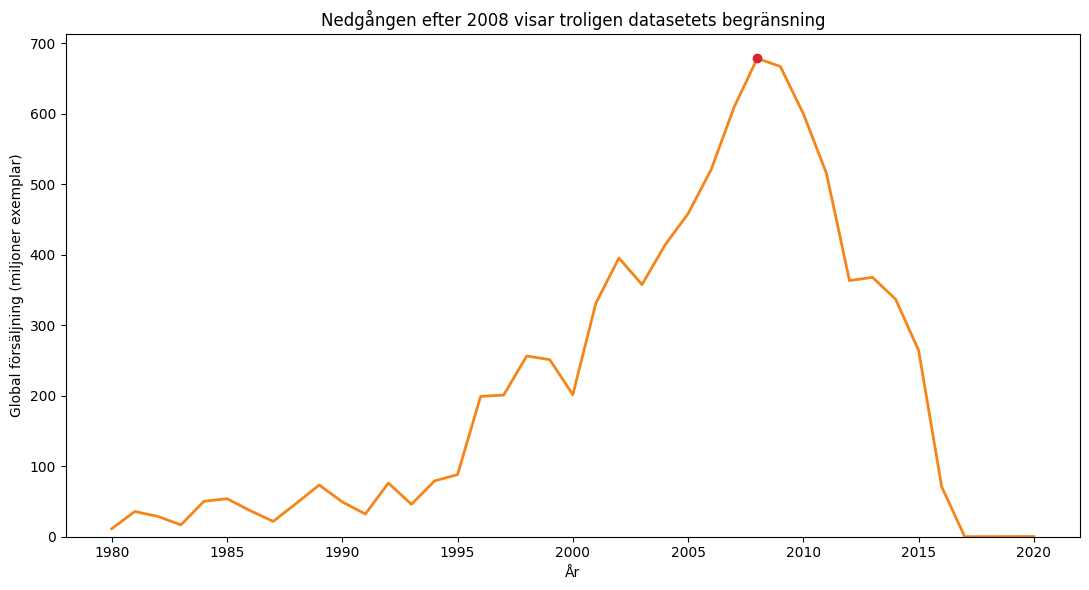

In [39]:
yearly_sales = (
    analysis_df.groupby("Year", as_index=False)["Global_Sales"]
    .sum()
    .sort_values("Year")
)

peak_year = yearly_sales.loc[yearly_sales["Global_Sales"].idxmax()]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(yearly_sales["Year"], yearly_sales["Global_Sales"], color="#F58518", linewidth=2)
ax.scatter(peak_year["Year"], peak_year["Global_Sales"], color="#D62728", zorder=3)

ax.set_title("Nedgången efter 2008 visar troligen datasetets begränsning")
ax.set_xlabel("År")
ax.set_ylabel("Global försäljning (miljoner exemplar)")
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

Diagrammet visar att försäljningen i datasetet toppar runt 2008 och sedan sjunker kraftigt. Jag tolkar inte det som att spelmarknaden faktiskt krympte på samma sätt. Eftersom spelmarknaden fortsatt växa globalt tyder nedgången snarare på att datasetet blir mindre komplett för senare år.